In [2]:
import plugin_loader  # noqa: F401
from abstract_pyprocessor import PyProcessor
import cv2
import matplotlib.pyplot as plt

Successfully loaded plugin: abstract_pyprocessor
Successfully loaded plugin: matched_filter_pyprocessor
Successfully loaded plugin: fmmorph_pyprocessor
Successfully loaded plugin: contour_pyprocessor


In [3]:
images_directory = '../images/'
annotations_directory = '../images/annotated/'
processed_directory = '../processed/'

images = {
    "0145.tif": "0145.png",
    "0146.tif": "0146.png",
    "0147.tif": "0147.png",
    "0148.tif": "0148.png",
    "0152.tif": "0152.png",
    "0154.tif": "0154.png",
    "0156.jpg": "0156.png",
    "0157.jpg": "0157.png",
    "0158.jpg": "0158.png",
}

methods = {
    "smf"
}

In [4]:
from joblib import Memory
import score

cache_directory = "./__segcache__"
memory = Memory(cache_directory, verbose=0)


@memory.cache
def benchmark(image_path: str, annotation_path: str, method: str) -> dict:
    image = cv2.imread(images_directory + image_path, cv2.IMREAD_GRAYSCALE)
    assert image is not None

    ground_truth = cv2.imread(
        annotations_directory + annotation_path, cv2.IMREAD_GRAYSCALE
    )
    assert ground_truth is not None

    PyProcessor.dispatch_execute(method, image)

    cv2.imwrite(
        f"{processed_directory}{method}_{image_path[: image_path.find('.')]}.png",
        image,
    )

    return {
        "image_path": image_path,
        "method_name": method,
        "iou": score.iou(image, ground_truth),
        "dice": score.dice(image, ground_truth),
        "percent_err": score.percent_err(image, ground_truth),
    }


for image_path, annotation_path in images.items():
    ground_truth = cv2.imread(
        annotations_directory + annotation_path, cv2.IMREAD_GRAYSCALE
    )
    assert ground_truth is not None

    for method in methods:
        benchmark.call(
            image_path=image_path, annotation_path=annotation_path, method=method
        )

In [5]:
def compare(image_path: str, annotation_path: str, method: str) -> None:
    image = cv2.imread(images_directory + image_path, cv2.IMREAD_COLOR_RGB)
    assert image is not None

    ground_truth = cv2.imread(
        annotations_directory + annotation_path, cv2.IMREAD_COLOR_RGB
    )
    assert ground_truth is not None

    prediction = cv2.imread(
        f"{processed_directory}{method}_{image_path[: image_path.find('.')]}.png",
        cv2.IMREAD_GRAYSCALE,
    )
    assert prediction is not None

    result = benchmark(image_path, annotation_path, method)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(ground_truth)
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(prediction, cmap="gray")
    metrics_text = (
        f"Prediction ({method})\n"
        f"IoU: {result['iou']:.4f} | Dice: {result['dice']:.4f}\n"
        f"Err: {result['percent_err']:.2%}"
    )
    axes[2].set_title(metrics_text, fontsize=10)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

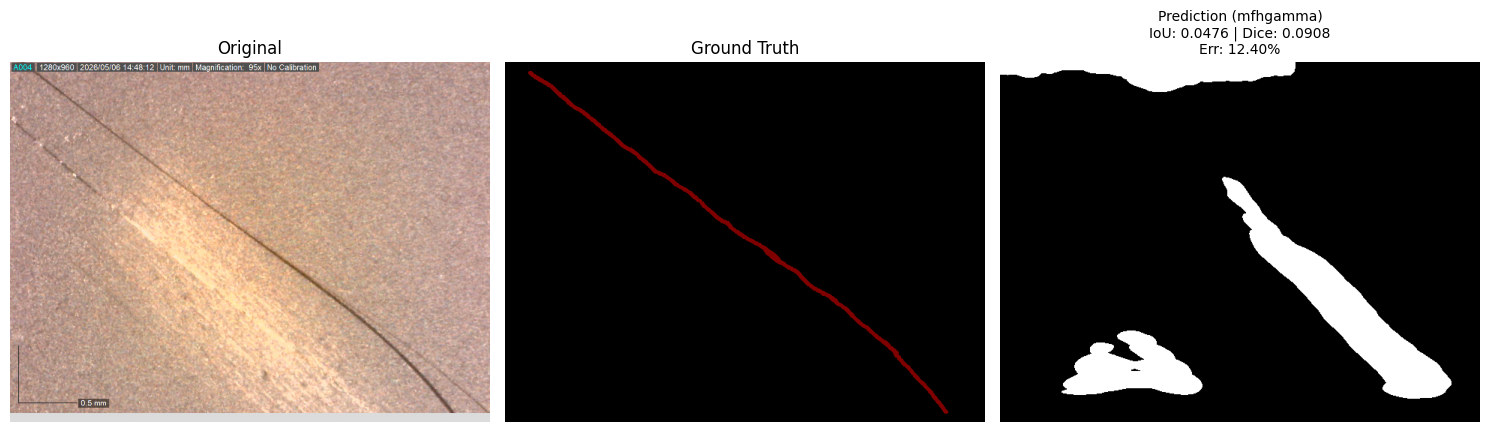

In [10]:
compare("0146.tif", "0146.png", "mfhgamma")

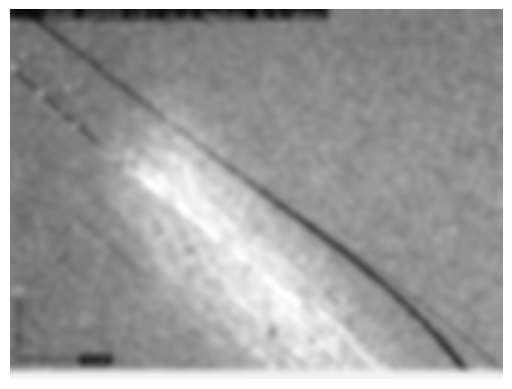

In [7]:
from matched_filter_strategy import (
    BoxBlur,
    GaussianBlur,
    GaussianMatcher,
    SigmoidStretcher,
    HysteresisThresholder,
    ConnectedComponentDenoiser
)
import numpy as np

test = cv2.imread('../images/0146.tif', cv2.IMREAD_GRAYSCALE)
assert test is not None

bb = BoxBlur()
response = bb.process(test)

gb = GaussianBlur()
response = gb.process(response)

gm = GaussianMatcher(sigma=4.0, L=32)
# response = gm.filter(response)

ss = SigmoidStretcher(steepness=10.0)
# response = ss.correct(response)

th = HysteresisThresholder()
# response = th.apply(response)

ccd = ConnectedComponentDenoiser(0.001)
# response = ccd.denoise(response)

test[:] = response

plt.imshow(test, cmap="gray")
plt.axis("off")
plt.show()

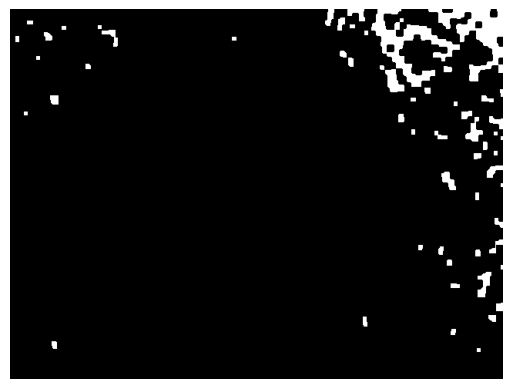

In [8]:
test2 = cv2.imread('../images/0145.tif', cv2.IMREAD_GRAYSCALE)
assert test2 is not None

PyProcessor.dispatch_execute('fmm', test2)

plt.imshow(test2, cmap='gray')
plt.axis('off')
plt.show()